# Regresión Lineal Múltiple — Predicción de Contaminación NO₂ en EE.UU.

## Dataset
US Pollution 2000-2021
Fuente: Kaggle — https://www.kaggle.com/datasets/alpacanonymous/us-pollution-20002021

## Objetivo
Predecir el nivel promedio diario de Dióxido de Nitrógeno (NO₂ Mean)
en estaciones de monitoreo de Estados Unidos usando regresión lineal múltiple

## Variable objetivo (Y)
`NO2 Mean` — Concentración promedio diaria de NO₂ en partes por billón (ppb)

## Features seleccionadas (X) — 14 variables
| # | Feature | Justificación |
|---|---|---|
| 1 | CO Mean |  combustión de motores |
| 2 | SO2 Mean | Coexiste con NO₂ en zonas industriales |
| 3 | O3 Mean | Relación química directa con NO₂ |
| 4 | CO 1st Max Value | Pico extremo de CO del día |
| 5 | SO2 1st Max Value | Pico industrial del día |
| 6 | O3 1st Max Value | Pico de reacción química del día |
| 7 | CO 1st Max Hour | Hora del pico indica tipo de fuente |
| 8 | SO2 1st Max Hour | Hora de actividad industrial |
| 9 | O3 1st Max Hour | Hora de mayor reacción química |
| 10 | Year | Tendencia histórica de reducción de emisiones |
| 11 | Month | Estacionalidad — más NO₂ en invierno |
| 12 | Day of week | Patrón laboral vs fin de semana |
| 13 | State | Contexto regional y regulatorio |
| 14 | City | Detalle urbano vs rural |

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
from matplotlib import pyplot as plt


In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Leer datos con Pandas
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Intelegencia Artificial/Dataset/pollution_2000_2021.csv')

# Crear columna dia de la semana desde la fecha
data['Date'] = pd.to_datetime(data['Date'])
data['day_of_week'] = data['Date'].dt.dayofweek

# Convertir texto a numero
data['State'] = data['State'].astype('category').cat.codes
data['City']  = data['City'].astype('category').cat.codes

# Extraer X e y igual que el inge
X = data[['CO Mean', 'SO2 Mean', 'O3 Mean',
          'CO 1st Max Value', 'SO2 1st Max Value', 'O3 1st Max Value',
          'CO 1st Max Hour', 'SO2 1st Max Hour', 'O3 1st Max Hour',
          'Year', 'Month', 'day_of_week',
          'State', 'City']]

y = data['NO2 Mean']
m = y.size

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'm       : {m}')

X shape : (608699, 14)
y shape : (608699,)
m       : 608699


## 2. Normalización de Características

Las features tienen escalas muy diferentes — Year va de 2000 a 2021
mientras CO Mean va de 0 a 7. Sin normalizar el gradiente converge
muy lento o diverge.

Se aplica normalización Z-score a cada feature:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

Resultado: todas las features quedan con media = 0
y desviación estándar = 1.

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()  # copia para no dañar X original
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X, axis=0)
    X_norm = (X_norm - mu) / sigma
    return X_norm, mu, sigma

# Llamar la funcion
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada    :', mu)
print('Desviacion estandar:', sigma)

Media calculada    : [3.37257985e-01 1.52335813e+00 2.84771521e-02 4.76798220e-01
 4.21027076e+00 3.89034515e-02 5.97104152e+00 8.85189067e+00
 1.07734693e+01 2.01104053e+03 6.50867013e+00 2.99508296e+00
 1.85622467e+01 7.73439204e+01]
Desviacion estandar: [2.82957482e-01 2.49509157e+00 1.22181780e-02 4.46320504e-01
 7.98378599e+00 1.50314396e-02 7.73937322e+00 6.77471420e+00
 3.30814962e+00 6.12255290e+00 3.31063025e+00 1.99656279e+00
 1.49656050e+01 4.00606954e+01]


In [ ]:
data.describe()

,Date,Year,Month,Day,State,City,O3 Mean,O3 1st Max Value,O3 1st Max Hour,O3 AQI,...,CO AQI,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,NO2 Mean,NO2 1st Max Value,NO2 1st Max Hour,NO2 AQI,day_of_week
count,608699,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,...,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000,608699.000000
mean,2011-07-16 14:35:09.909824,2011.040529,6.508670,15.737176,18.562247,77.343920,0.028477,0.038903,10.773469,39.112517,...,5.377387,1.523358,4.210271,8.851891,5.568708,11.738067,23.610711,11.606845,22.124240,2.995083
min,2000-01-01 00:00:00,2000.000000,1.000000,1.000000,0.000000,0.000000,-0.000706,0.000000,7.000000,0.000000,...,0.000000,-2.508333,-2.300000,0.000000,0.000000,-4.629167,-4.400000,0.000000,0.000000,0.000000
25%,2006-07-18 00:00:00,2006.000000,4.000000,8.000000,4.000000,42.000000,0.019647,0.029000,9.000000,27.000000,...,2.000000,0.187500,0.600000,3.000000,0.000000,4.978261,11.200000,5.000000,10.000000,1.000000
50%,2012-01-07 00:00:00,2012.000000,7.000000,16.000000,15.000000,81.000000,0.028235,0.038000,10.000000,35.000000,...,5.000000,0.666667,1.700000,8.000000,1.000000,9.541667,21.800000,9.000000,20.000000,3.000000
75%,2016-09-21 00:00:00,2016.000000,9.000000,23.000000,34.000000,106.000000,0.036765,0.048000,11.000000,44.000000,...,7.000000,1.772727,4.000000,13.000000,6.000000,16.304348,33.700000,20.000000,31.000000,5.000000
max,2021-10-31 00:00:00,2021.000000,12.000000,31.000000,47.000000,147.000000,0.107353,0.140000,23.000000,237.000000,...,201.000000,321.625000,351.000000,23.000000,200.000000,140.650000,269.200000,23.000000,133.000000,6.000000
std,NaN,6.122558,3.310633,8.806949,14.965617,40.060728,0.012218,0.015031,3.308152,22.480864,...,5.142873,2.495094,7.983793,6.774720,10.736164,9.083091,15.412489,7.881014,14.610125,1.996564


## 3. Término de Intersección

Se agrega una columna de unos a X para incluir el término
de sesgo θ₀ en el producto matricial:

$$h_\theta(x) = \theta_0 + \theta_1x_1 + \theta_2x_2 + \cdots + \theta_{14}x_{14} = \theta^Tx$$

In [ ]:
# Agregar termino de interseccion
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print(X)
print(X.shape)
print(X[0])

[[ 1.          1.91438307  0.59181871 ...  1.00418432 -1.10668742
   0.61546809]
 [ 1.          2.5778043   0.17433223 ...  1.5050451  -1.10668742
   0.61546809]
 [ 1.          5.03694761  1.49358922 ... -1.50011959 -1.10668742
   0.61546809]
 ...
 [ 1.         -0.83849341 -0.47985058 ... -1.50011959  1.9002074
   0.46569535]
 [ 1.         -0.95629556 -0.48333582 ... -0.99925881  1.9002074
   0.46569535]
 [ 1.         -1.00047181 -0.46358664 ... -0.49839803  1.9002074
   0.46569535]]
(608699, 15)
[ 1.          1.91438307  0.59181871 -0.71304839  3.8609066   0.59993207
  0.07295033  2.20030201  1.79315451 -0.23380724 -1.8032558  -1.66393397
  1.00418432 -1.10668742  0.61546809]


## 4. Función de Costo

Mide qué tan mal predice el modelo. A menor J(θ), mejor el modelo:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

Con theta = ceros el costo inicial es **110.14** — el modelo no sabe nada todavía.

In [ ]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = 0
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [ ]:
# Inicializar theta en ceros
theta = np.zeros(X.shape[1])

# Calcular costo inicial
J = computeCostMulti(X, y, theta)
print('Con theta = ceros')
print('Costo calculado = %.2f' % J)

Con theta = ceros
Costo calculado = 110.14


## 5. Descenso por Gradiente

Algoritmo que minimiza J(θ) actualizando theta en cada iteración:

$$\theta := \theta - \frac{\alpha}{m} X^T(X\theta - y)$$

Donde:
- **α = 0.1** — tasa de aprendizaje
- **400 iteraciones** — número de pasos
- **theta inicial = ceros** — el modelo parte sin conocimiento previo

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

## 6. Convergencia del Gradiente

La curva muestra cómo bajó el costo en cada iteración.
Una curva suave que se aplana confirma convergencia correcta.

- **Costo inicial:** 110.14
- **Costo final:** 16.97
- **Reducción:** 85%

In [ ]:

alpha     = 0.1
num_iters = 1000

# Inicializar theta
theta = np.zeros(X.shape[1])

# Ejecutar descenso por gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

print("\n=== RESULTADOS ===")
print(f"Theta       : {theta}")
print(f"Costo inicio: {J_history[0]:.2f}")
print(f"Costo final : {J_history[-1]:.2f}")

mejora = ((J_history[0] - J_history[-1]) / J_history[0]) * 100
print(f"Mejora (%)  : {mejora:.2f}%")


=== RESULTADOS ===
Theta       : [11.73806745  1.20123174  1.49815513 -6.35145597  3.33575272  0.08931035
  5.22108004  0.28278753  0.19360128  0.47403452 -0.2624474  -0.48848305
 -0.65832385  0.03682161  0.05697769]
Costo inicio: 87.09
Costo final : 16.97
Mejora (%)  : 80.52%


Text(0.5, 1.0, 'Convergencia del Descenso por Gradiente')

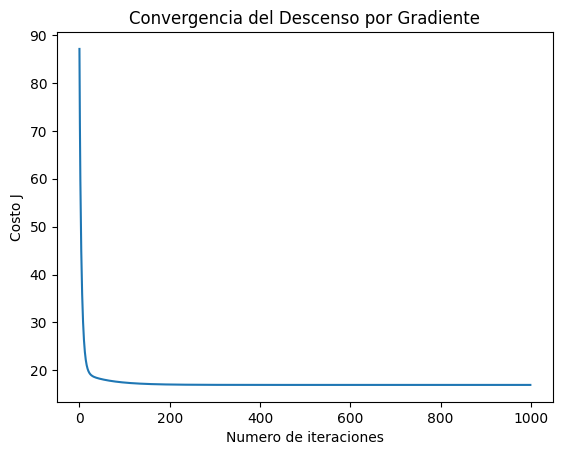

In [ ]:
# Graficar como bajo el costo en cada iteracion
plt.plot(np.arange(len(J_history)), J_history)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Descenso por Gradiente')

## 7. Inferencias

Una vez entrenado el modelo, se realizan predicciones para
nuevas estaciones de monitoreo.

**Importante:** los datos nuevos deben normalizarse con los
mismos μ y σ calculados durante el entrenamiento, de lo
contrario el modelo predecirá valores incorrectos.

Ejemplo: Predicción de NO₂ para una estación en California,
enero 2015, día lunes.

In [ ]:
# Datos de una nueva estacion de monitoreo
# California, enero 2015, lunes
X_pred = np.array([
    0.54,   # CO Mean
    1.20,   # SO2 Mean
    0.03,   # O3 Mean
    0.80,   # CO 1st Max Value
    2.10,   # SO2 1st Max Value
    0.05,   # O3 1st Max Value
    8,      # CO 1st Max Hour
    10,     # SO2 1st Max Hour
    11,     # O3 1st Max Hour
    2015,   # Year
    1,      # Month
    0,      # day_of_week (lunes)
    4,      # State (California)
    81      # City (Los Angeles)
])

# Normalizar con los mismos mu y sigma del entrenamiento
X_pred_norm = (X_pred - mu) / sigma

# Agregar el 1 del bias
X_pred_norm = np.concatenate([[1], X_pred_norm])

# Predecir
prediccion = np.dot(X_pred_norm, theta)
print('Estacion  : Los Angeles, California')
print('Fecha     : Enero 2015, Lunes')
print('NO2 predicho: %.2f ppb' % prediccion)

Estacion  : Los Angeles, California
Fecha     : Enero 2015, Lunes
NO2 predicho: 19.50 ppb
